In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Convert to DataFrame (important for assignment)
df_train = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))
df_train['label'] = y_train

df_test = pd.DataFrame(X_test.reshape(X_test.shape[0], -1))
df_test['label'] = y_test

print(df_train.head())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  label  
0    0      5  
1    0      0  
2    0      4  
3    0      1  
4    0      9  

[5 rows x 785 columns]


In [ ]:
# Statistical values
print(df_train.describe())

# Mean, Median, Std
print("Mean:", df_train.mean().mean())
print("Median:", df_train.median().median())
print("Std Dev:", df_train.std().mean())

             0        1        2        3        4        5        6        7  \
count  60000.0  60000.0  60000.0  60000.0  60000.0  60000.0  60000.0  60000.0   
mean       0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
std        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
min        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
25%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
50%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
75%        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
max        0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

             8        9  ...           775           776           777  \
count  60000.0  60000.0  ...  60000.000000  60000.000000  60000.000000   
mean       0.0      0.0  ...      0.088867      0.045633      0.019283   
std        0.0      0.0  ...      3.956189      

In [ ]:
print(df_train.isnull().sum().sum())
print(df_test.isnull().sum().sum())

0
0


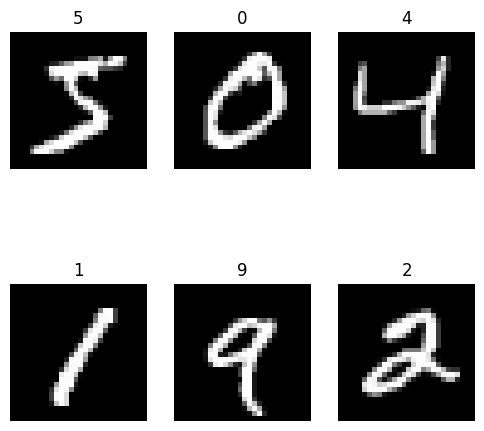

In [ ]:
import matplotlib.pyplot as plt

# Show images
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# One-hot encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(5,5),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,901 (878.52 KB)

 Trainable params: 224,901 (878.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9295 - loss: 0.2309 - val_accuracy: 0.9824 - val_loss: 0.0608
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9739 - loss: 0.0861 - val_accuracy: 0.9852 - val_loss: 0.0486
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9803 - loss: 0.0657 - val_accuracy: 0.9871 - val_loss: 0.0454
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9845 - loss: 0.0524 - val_accuracy: 0.9888 - val_loss: 0.0391
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9897 - val_loss: 0.0365
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9889 - loss: 0.0362 - val_accuracy: 0.9901 - val_loss: 0.0380
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9903 - loss: 0.0319 - val_accuracy: 0.9908 - val_loss: 0.0348
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.9917 -

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9918 - loss: 0.0280
Accuracy: 0.9918000102043152


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


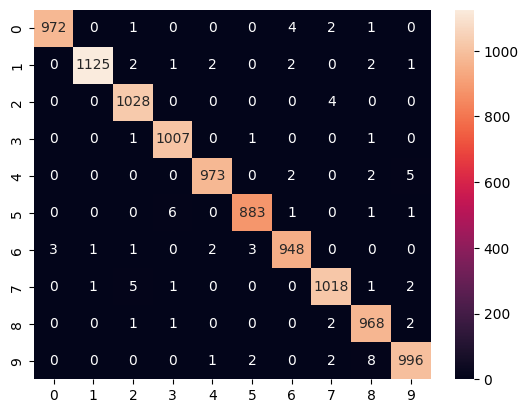

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

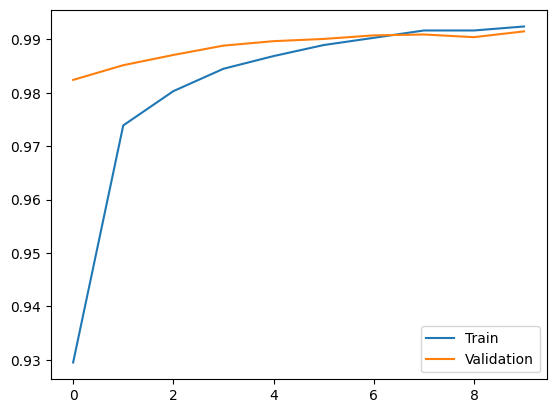

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
# Change filters
Conv2D(128,(3,3))

<Conv2D name=conv2d_2, built=False>

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9940 - loss: 0.0173 - val_accuracy: 0.9907 - val_loss: 0.0442
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9941 - loss: 0.0181 - val_accuracy: 0.9913 - val_loss: 0.0419
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9941 - loss: 0.0166 - val_accuracy: 0.9898 - val_loss: 0.0483
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9909 - val_loss: 0.0442
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9919 - val_loss: 0.0435


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.9916 - val_loss: 0.0388
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9960 - loss: 0.0128 - val_accuracy: 0.9928 - val_loss: 0.0461
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9917 - val_loss: 0.0429
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9961 - loss: 0.0115 - val_accuracy: 0.9926 - val_loss: 0.0439


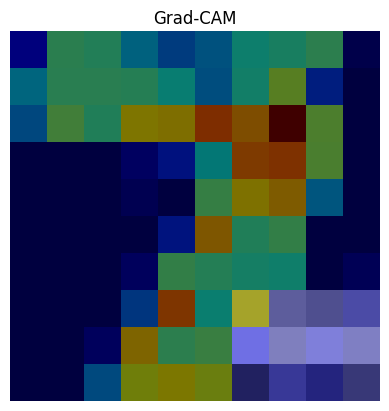

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, image):

    # Ensure model is built (this was already handled by previous steps, but it's good practice)
    # However, for creating grad_model, we need to ensure the graph is traceable from a new input.

    # Find last Conv layer's name
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    if last_conv_layer_name is None:
        raise ValueError("No Conv2D layer found in the model.")

    # Define a new Input layer for the grad_model to trace the graph correctly
    input_tensor = tf.keras.Input(shape=image.shape[1:])

    # Manually trace the input_tensor through the model's layers
    x = input_tensor
    intermediate_conv_output = None
    for layer in model.layers:
        # Pass the tensor through the layer
        x = layer(x)
        # If this is the target convolutional layer, store its output
        if layer.name == last_conv_layer_name:
            intermediate_conv_output = x

    if intermediate_conv_output is None:
        # This should ideally not happen if last_conv_layer_name was found
        raise ValueError(f"Could not trace output for layer '{last_conv_layer_name}'.")

    # Create grad model using the new input_tensor and the traced outputs
    grad_model = tf.keras.models.Model(
        inputs=input_tensor,
        outputs=[intermediate_conv_output, x] # x is the final output of the model
    )

    # Convert to tensor
    image = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image, training=False)

        # Handle cases where predictions might be all zeros or empty
        if predictions.shape[0] == 0 or tf.reduce_sum(tf.abs(predictions[0])) == 0:
            class_idx = tf.constant(0, dtype=tf.int64) # Default to class 0
        else:
            class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    # Handle cases where grads might be None or all zeros
    if grads is None or tf.reduce_sum(tf.abs(grads)) == 0:
        return np.zeros_like(image.squeeze())

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    # Add a small epsilon to avoid division by zero if max_val is 0
    max_val = tf.reduce_max(heatmap)
    heatmap /= (max_val + tf.keras.backend.epsilon())

    return heatmap.numpy()


# Test image
img = X_test[0]
img_array = np.expand_dims(img, axis=0)

# Run Grad-CAM
heatmap = get_gradcam_heatmap(model, img_array)

# Plot
plt.imshow(img.squeeze(), cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()